# Backward Lens: GPT-2 gradient factors in vocabulary space

This notebook demonstrates `BackwardLens` on a small, fixed set of GPT-2 next-token targets. It reproduces the *method* of projecting forward inputs and backward signals into vocabulary space; it is not a paper-scale replication and makes no causal claim from token rankings alone. All examples and layers are declared before analysis, and all outcomes are shown without filtering.

The implementation follows [Katz et al. (2024)](https://aclanthology.org/2024.emnlp-main.142/). Gradient signs below are raw `d(loss) / d(tensor)` signs; gradient descent subtracts them.

## Geometry

For GPT-2's `[in, out]` `Conv1D` weight layout, token-position factors reconstruct the gradient as

$$\nabla_W L = \sum_i x_i \delta_i^\mathsf{T} = X^\mathsf{T}\Delta.$$

For FF1 (`c_fc`), the residual-width factor is the forward input $x_i$. For FF2 (`c_proj`), it is the backward signal $\delta_i$. `BackwardLens` applies a fresh `ln_final` and unembedding to those residual-width rows.

In [1]:
import gc
import os
import warnings

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub.utils import logging as hf_hub_logging
from IPython.display import display
from transformers.utils import logging as hf_logging
from typeguard import InstrumentationWarning

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="@typechecked only supports instrumenting functions wrapped.*",
        category=InstrumentationWarning,
    )
    from transformer_lens.model_bridge import TransformerBridge
    from transformer_lens.tools.analysis import BackwardLens

hf_hub_logging.set_verbosity_error()
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
torch.manual_seed(0)

DEVICE = "cpu"  # Stable saved outputs and portable notebook validation.
DETAILED_LAYERS = (0, 2, 4, 6, 8, 10, 11)
EXAMPLES = (
    ("The capital of France is", " Paris"),
    ("The capital of Italy is", " Rome"),
    ("The largest planet in the Solar System is", " Jupiter"),
)

pd.DataFrame(EXAMPLES, columns=["prompt", "one-token target"])

,prompt,one-token target
0,The capital of France is,Paris
1,The capital of Italy is,Rome
2,The largest planet in the Solar System is,Jupiter


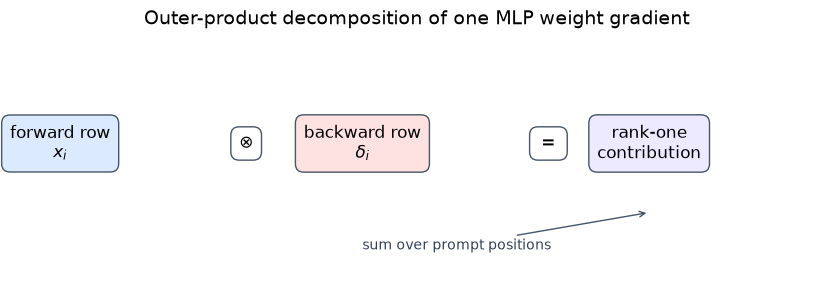

In [2]:
# Original schematic: each position contributes one outer product.
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
boxes = [
    (0.04, 0.55, "forward row\n$x_i$", "#dbeafe"),
    (0.28, 0.55, r"$\otimes$", "white"),
    (0.43, 0.55, "backward row\n" r"$\delta_i$", "#fee2e2"),
    (0.67, 0.55, "$=$", "white"),
    (0.80, 0.55, "rank-one\ncontribution", "#ede9fe"),
]
for x, y, label, color in boxes:
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", facecolor=color, edgecolor="#475569"),
    )
ax.annotate(
    "sum over prompt positions",
    xy=(0.80, 0.27),
    xytext=(0.43, 0.12),
    arrowprops=dict(arrowstyle="->", color="#475569"),
    color="#334155",
)
ax.set_title("Outer-product decomposition of one MLP weight gradient", fontsize=14)
plt.show()

## Load a raw GPT-2 Bridge

Backward Lens requires original GPT-2 weights. Do not enable compatibility mode or process the weights. CPU float32 is used deliberately so the saved notebook is portable; change `DEVICE` for interactive exploration.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = TransformerBridge.boot_transformers(
        "gpt2", device=DEVICE, dtype=torch.float32
    )
model.eval()
lens = BackwardLens(model)
print("Loaded a raw GPT-2 TransformerBridge.")

Loaded a raw GPT-2 TransformerBridge.


In [4]:
def final_position_summary(result):
    rows = []
    for layer_result in result.layers:
        ff2 = layer_result.output_projection
        rows.append(
            {
                "layer": layer_result.layer,
                "raw target rank": int(
                    ff2.gradient_descent_target_ranks(result.target_token_id)[-1]
                ),
                "normalized target rank": int(
                    ff2.gradient_descent_target_ranks(
                        result.target_token_id, normalized=True
                    )[-1]
                ),
                "final-position VJP norm": float(ff2.factor_norms[-1]),
            }
        )
    return pd.DataFrame(rows)


prompt, target = EXAMPLES[0]
primary_result = lens.analyze(prompt, target, DETAILED_LAYERS, normalized=True)
primary_layer_summary = final_position_summary(primary_result)
print(
    f"Analyzed {len(primary_result.prompt_token_ids)} positions across "
    f"{len(primary_result.layers)} layers."
)

Analyzed 6 positions across 7 layers.


## Vocabulary-facing factor tables

FF1 top tokens describe forward residual directions. FF2 bottom tokens use the ascending raw-gradient ordering relevant to a subtracted gradient-descent update. The layer-by-position table keeps those two factors separate. The final-position comparison shows how unit normalization changes FF2 token ordering while retaining and coloring by the original VJP norm.

The sign panel compares the largest raw-gradient logits with the ordering obtained by subtracting those same projected logits. It is deliberately labeled as an ordering diagnostic, not as $P(-v)$: final LayerNorm makes direct factor negation a different operation. None of these tables are direct model predictions.

,layer,position,prompt token,FF1 top raw directions,FF2 bottom raw (update ordering)
0,0,0,<|endoftext|>,"<|endoftext|>, Advertisements, \n","%], Thumbnail, 女"
1,0,1,The,"The, the, The","ixel, Medium, iop"
2,0,2,capital,"capital, capital, Capital","inventoryQuantity, catentry, }}}"
3,0,3,of,"of, of, Of","Archdemon, ortium, Difference"
4,0,4,France,"France, France, French","anton, Seasons, figure"
5,0,5,is,"is, also, was","adr, adian, umn"
6,2,0,<|endoftext|>,",, the, \n","ometric, Associates, 76561"
7,2,1,The,"latest, following, Official","orescent, oro, ulhu"
8,2,2,capital,"capital, punishment, penalty","illary, fig, Variant"
9,2,3,of,"the, course, interest","uably, iqueness, uments"


,layer,VJP norm,raw FF2 bottom tokens,normalized FF2 bottom tokens
0,0,6.557e-01,"adr, adian, umn, itia, igmatic","adr, adian, umn, itia, igmatic"
1,2,1.442e+00,"EStreamFrame, ORPG, Dise, misconception, senal","EStreamFrame, ORPG, Dise, misconception, senal"
2,4,1.329e+00,"Diseases, Firstly, Feet, heses, Differences","Diseases, Firstly, Feet, heses, Differences"
3,6,1.042e+00,"Tycoon, 76561, Osiris, Modes, Memories","Tycoon, 76561, Osiris, Modes, Memories"
4,8,4.872e-01,"Paris, Paris, Cologne, Copenhagen, Rome","Paris, Paris, Cologne, Copenhagen, Rome"
5,10,2.749e-01,"Paris, Paris, Copenhagen, Cologne, Kyoto","Paris, Paris, Copenhagen, Cologne, Kyoto"
6,11,2.609e-01,"Paris, Paris, Copenhagen, Marse, France","Paris, Paris, Copenhagen, Marse, France"


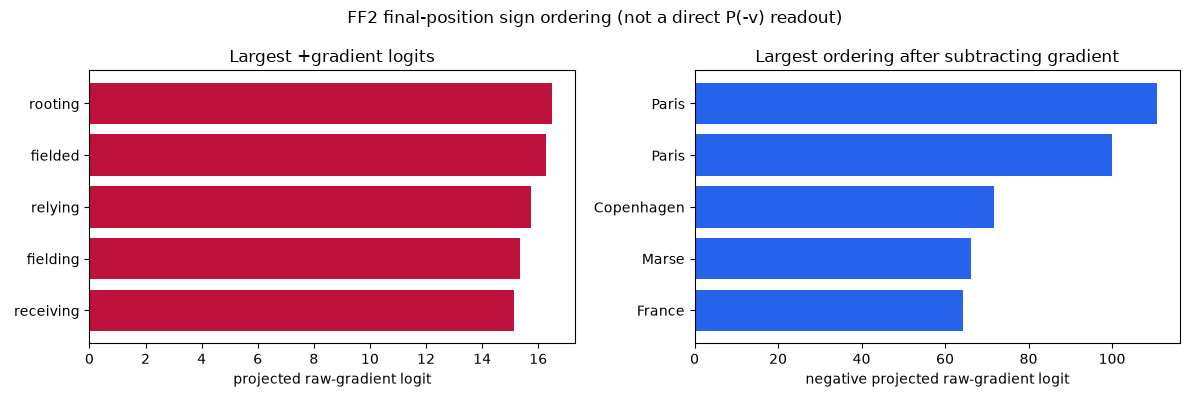

In [5]:
def clean_token(token):
    return token.replace("\n", "\\n")


token_ids = primary_result.prompt_token_ids.tolist()
position_tokens = [
    clean_token(model.tokenizer.decode([token_id])) for token_id in token_ids
]

layer_position_rows = []
for layer_result in primary_result.layers:
    ff1_top = layer_result.input_projection.top_tokens(model.tokenizer, k=3)
    ff2_bottom = layer_result.output_projection.bottom_tokens(model.tokenizer, k=3)
    for position, prompt_token in enumerate(position_tokens):
        layer_position_rows.append(
            {
                "layer": layer_result.layer,
                "position": position,
                "prompt token": prompt_token,
                "FF1 top raw directions": ", ".join(
                    map(clean_token, ff1_top[position])
                ),
                "FF2 bottom raw (update ordering)": ", ".join(
                    map(clean_token, ff2_bottom[position])
                ),
            }
        )
display(pd.DataFrame(layer_position_rows))

final_position = -1
norm_comparison_rows = []
for layer_result in primary_result.layers:
    ff2 = layer_result.output_projection
    raw_bottom = ff2.bottom_tokens(model.tokenizer, k=5)[final_position]
    normalized_bottom = ff2.bottom_tokens(
        model.tokenizer, k=5, normalized=True
    )[final_position]
    norm_comparison_rows.append(
        {
            "layer": layer_result.layer,
            "VJP norm": float(ff2.factor_norms[final_position]),
            "raw FF2 bottom tokens": ", ".join(map(clean_token, raw_bottom)),
            "normalized FF2 bottom tokens": ", ".join(
                map(clean_token, normalized_bottom)
            ),
        }
    )
norm_comparison = pd.DataFrame(norm_comparison_rows)
display(
    norm_comparison.style.set_uuid("ff2-norm-comparison")
    .background_gradient(cmap="viridis", subset=["VJP norm"])
    .format({"VJP norm": "{:.3e}"})
)

last = primary_result.layer(DETAILED_LAYERS[-1]).output_projection
raw_top = last.top(k=5)
raw_bottom = last.bottom(k=5)
top_ids = raw_top.indices[final_position].tolist()
bottom_ids = raw_bottom.indices[final_position].tolist()
top_tokens = [clean_token(model.tokenizer.decode([token_id])) for token_id in top_ids]
bottom_tokens = [
    clean_token(model.tokenizer.decode([token_id])) for token_id in bottom_ids
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(top_tokens, raw_top.values[final_position].numpy(), color="#be123c")
axes[0].invert_yaxis()
axes[0].set(
    xlabel="projected raw-gradient logit",
    title="Largest +gradient logits",
)
axes[1].barh(
    bottom_tokens, -raw_bottom.values[final_position].numpy(), color="#2563eb"
)
axes[1].invert_yaxis()
axes[1].set(
    xlabel="negative projected raw-gradient logit",
    title="Largest ordering after subtracting gradient",
)
fig.suptitle("FF2 final-position sign ordering (not a direct P(-v) readout)")
fig.tight_layout()
plt.show()

## Reconstruction error and compact gradient rank

The gradient rank is estimated from the small factor core rather than by taking an expensive SVD of the full MLP matrix. The estimate uses a relative singular-value threshold of $10^{-5}$ and is bounded by the number of prompt positions.

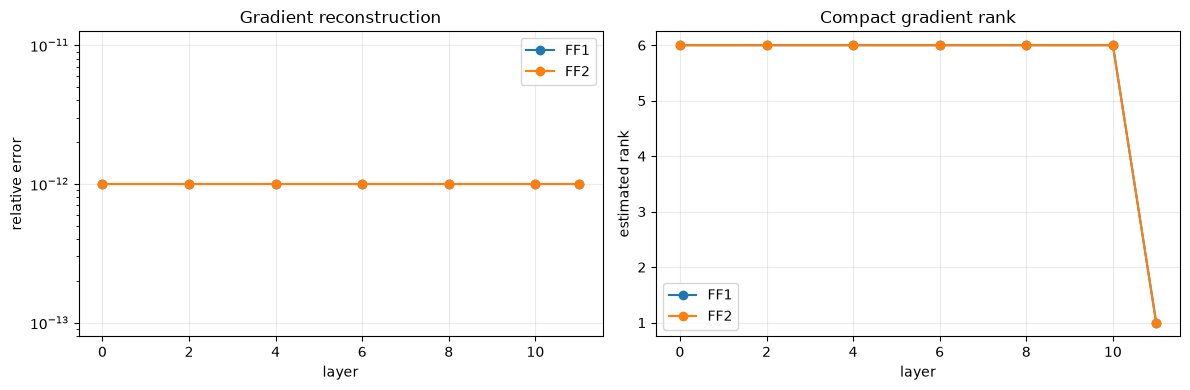

,layer,matrix,relative reconstruction error,compact numerical rank
0,0,FF1,0.000e+00,6
1,0,FF2,0.000e+00,6
2,2,FF1,0.000e+00,6
3,2,FF2,0.000e+00,6
4,4,FF1,0.000e+00,6
5,4,FF2,0.000e+00,6
6,6,FF1,0.000e+00,6
7,6,FF2,0.000e+00,6
8,8,FF1,0.000e+00,6
9,8,FF2,0.000e+00,6


In [6]:
def compact_gradient_rank(factors, relative_threshold=1e-5):
    x = factors.forward_inputs
    delta = factors.output_gradients
    _, rx = torch.linalg.qr(x.T, mode="reduced")
    _, rd = torch.linalg.qr(delta.T, mode="reduced")
    singular_values = torch.linalg.svdvals(rx @ rd.T)
    threshold = singular_values.max() * relative_threshold
    return int((singular_values > threshold).sum())


diagnostic_rows = []
for layer_result in primary_result.layers:
    for name, matrix in (
        ("FF1", layer_result.input_projection),
        ("FF2", layer_result.output_projection),
    ):
        diagnostic_rows.append(
            {
                "layer": layer_result.layer,
                "matrix": name,
                "relative reconstruction error": (
                    matrix.factors.relative_reconstruction_error
                ),
                "compact numerical rank": compact_gradient_rank(matrix.factors),
            }
        )
diagnostics = pd.DataFrame(diagnostic_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for matrix_name, group in diagnostics.groupby("matrix"):
    axes[0].plot(
        group["layer"],
        np.maximum(group["relative reconstruction error"], 1e-12),
        marker="o",
        label=matrix_name,
    )
    axes[1].plot(
        group["layer"],
        group["compact numerical rank"],
        marker="o",
        label=matrix_name,
    )
axes[0].set(
    yscale="log",
    xlabel="layer",
    ylabel="relative error",
    title="Gradient reconstruction",
)
axes[1].set(xlabel="layer", ylabel="estimated rank", title="Compact gradient rank")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
plt.show()
diagnostics_for_display = diagnostics.copy()
diagnostics_for_display["relative reconstruction error"] = diagnostics_for_display[
    "relative reconstruction error"
].map(lambda value: f"{value:.3e}")
display(diagnostics_for_display)

## Target-token ranks: raw versus Normalized Logit Lens

Ranks are zero-based and ascending in raw-gradient space: rank 0 is the smallest projected FF2 gradient logit. Lower is therefore the update-relevant ordering, but this remains a directional diagnostic rather than a prediction of an optimizer step.

,layer,final-position VJP norm,raw target rank percentile,normalized target rank percentile
0,0,0.655670,80.9,80.9
1,2,1.442085,41.3,41.4
2,4,1.329280,11.2,11.2
3,6,1.042345,4.4,4.4
4,8,0.487238,0.0,0.0
5,10,0.274904,0.0,0.0
6,11,0.260877,0.0,0.0


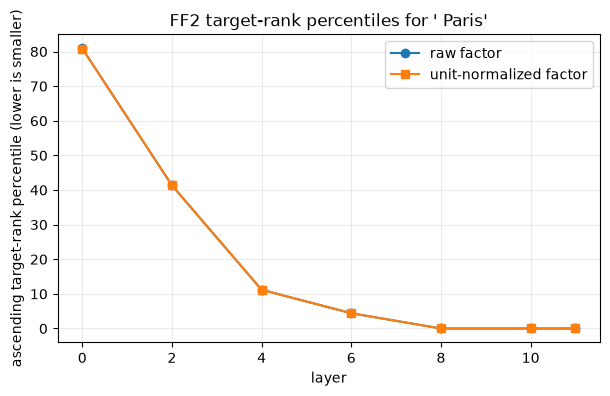

In [7]:
# Exact ranks can move by one across numeric backends when vocabulary logits are nearly tied.
# Keep them in primary_layer_summary, but display stable vocabulary percentiles.
vocab_size = primary_result.layers[0].output_projection.vocabulary_logits.shape[-1]
rank_percentiles = primary_layer_summary[["layer", "final-position VJP norm"]].copy()
rank_percentiles["raw target rank percentile"] = (
    100 * primary_layer_summary["raw target rank"] / vocab_size
)
rank_percentiles["normalized target rank percentile"] = (
    100 * primary_layer_summary["normalized target rank"] / vocab_size
)
display(
    rank_percentiles.round(
        {
            "final-position VJP norm": 8,
            "raw target rank percentile": 1,
            "normalized target rank percentile": 1,
        }
    )
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    rank_percentiles["layer"],
    rank_percentiles["raw target rank percentile"],
    marker="o",
    label="raw factor",
)
ax.plot(
    rank_percentiles["layer"],
    rank_percentiles["normalized target rank percentile"],
    marker="s",
    label="unit-normalized factor",
)
ax.set(
    xlabel="layer",
    ylabel="ascending target-rank percentile (lower is smaller)",
    title=f"FF2 target-rank percentiles for {target!r}",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## VJP norm heatmap

FF2 factor norms are norms of the residual-width vector-Jacobian products (VJPs). The logarithmic heatmap exposes both token-position and layer variation without discarding low-norm rows.

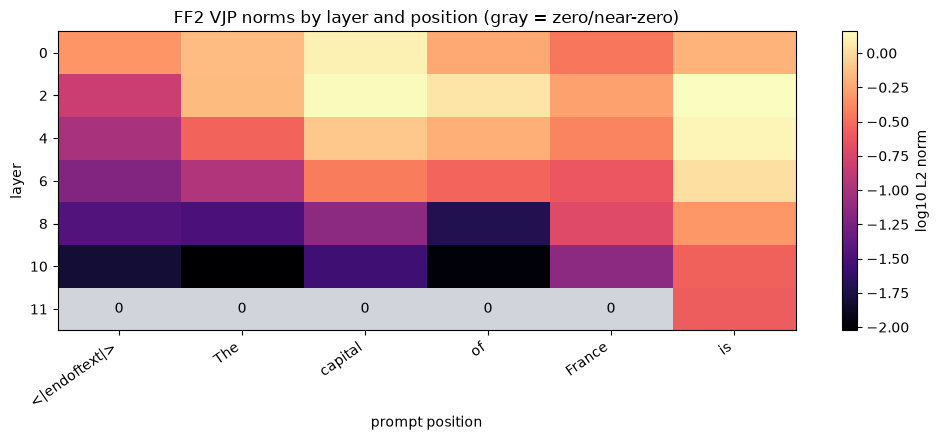

Near-zero threshold: 1.442e-08


In [8]:
vjp_norms = np.stack(
    [layer.output_projection.factor_norms.numpy() for layer in primary_result.layers]
)
near_zero_threshold = max(
    float(vjp_norms.max()) * 1e-8, torch.finfo(torch.float32).tiny
)
near_zero_mask = vjp_norms <= near_zero_threshold
log_vjp_norms = np.log10(np.maximum(vjp_norms, near_zero_threshold))
masked_log_vjp_norms = np.ma.masked_where(near_zero_mask, log_vjp_norms)
cmap = plt.colormaps["magma"].copy()
cmap.set_bad(color="#d1d5db")

fig, ax = plt.subplots(figsize=(10, 4.5))
image = ax.imshow(masked_log_vjp_norms, aspect="auto", cmap=cmap)
ax.set_yticks(range(len(DETAILED_LAYERS)), labels=DETAILED_LAYERS)
ax.set_xticks(
    range(len(position_tokens)), labels=position_tokens, rotation=35, ha="right"
)
for layer_index, position_index in np.argwhere(near_zero_mask):
    label = "0" if vjp_norms[layer_index, position_index] == 0 else "≈0"
    ax.text(position_index, layer_index, label, ha="center", va="center")
ax.set(
    xlabel="prompt position",
    ylabel="layer",
    title="FF2 VJP norms by layer and position (gray = zero/near-zero)",
)
fig.colorbar(image, ax=ax, label="log10 L2 norm")
fig.tight_layout()
plt.show()
print(f"Near-zero threshold: {near_zero_threshold:.3e}")

## Beyond-paper diagnostic: contribution size and cumulative reconstruction

For one middle-layer FF2 gradient, the Frobenius norm of position $i$'s outer product is $\lVert x_i\rVert_2\lVert\delta_i\rVert_2$. The contribution bars retain prompt order. The cumulative curve adds positions from largest to smallest contribution norm and reports how much of the full reconstructed gradient remains.

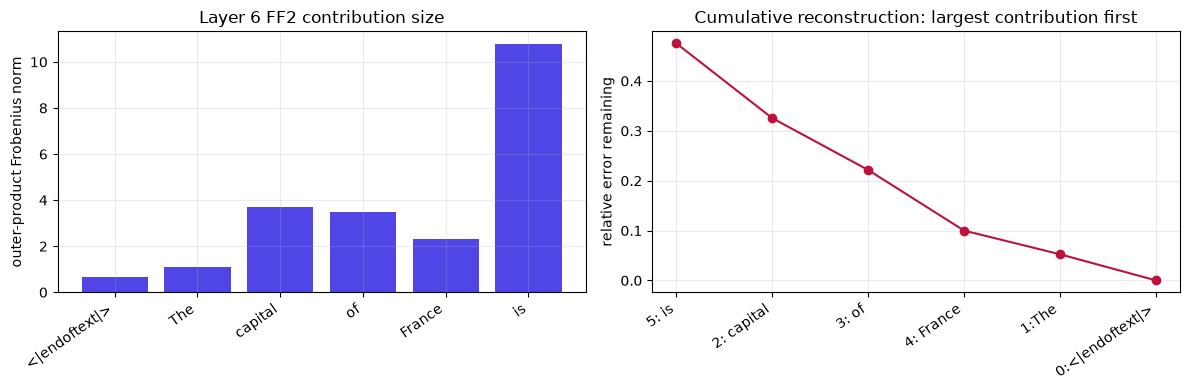

In [9]:
middle_layer = DETAILED_LAYERS[len(DETAILED_LAYERS) // 2]
factors = primary_result.layer(middle_layer).output_projection.factors
contribution_norms = (
    factors.forward_inputs.norm(dim=-1) * factors.output_gradients.norm(dim=-1)
).numpy()
sorted_positions = np.argsort(-contribution_norms, kind="stable")
running = torch.zeros_like(factors.reconstructed_gradient)
full_norm = factors.reconstructed_gradient.norm().clamp_min(
    torch.finfo(torch.float32).eps
)
remaining_error = []
for position in sorted_positions:
    x_row = factors.forward_inputs[position]
    delta_row = factors.output_gradients[position]
    running += torch.outer(x_row, delta_row)
    remaining_error.append(
        float((factors.reconstructed_gradient - running).norm() / full_norm)
    )
sorted_labels = [
    f"{position}:{position_tokens[position]}" for position in sorted_positions
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(position_tokens)), contribution_norms, color="#4f46e5")
axes[0].set_xticks(
    range(len(position_tokens)), labels=position_tokens, rotation=35, ha="right"
)
axes[0].set(
    ylabel="outer-product Frobenius norm",
    title=f"Layer {middle_layer} FF2 contribution size",
)
axes[1].plot(range(len(sorted_positions)), remaining_error, marker="o", color="#be123c")
axes[1].set_xticks(
    range(len(sorted_positions)), labels=sorted_labels, rotation=35, ha="right"
)
axes[1].set(
    ylabel="relative error remaining",
    title="Cumulative reconstruction: largest contribution first",
)
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Predeclared examples: report every outcome

The remaining examples are analyzed only at GPT-2's final layer to keep the demo compact. The table reports whether unit normalization improves, worsens, or leaves unchanged the target's ascending raw-gradient rank. No example is removed based on its result.

In [10]:
comparison_rows = []
for example_index, (example_prompt, example_target) in enumerate(EXAMPLES):
    if example_index == 0:
        result = primary_result
    else:
        result = lens.analyze(
            example_prompt,
            example_target,
            [DETAILED_LAYERS[-1]],
            normalized=True,
        )
    summary = final_position_summary(result).iloc[-1]
    raw_rank = int(summary["raw target rank"])
    normalized_rank = int(summary["normalized target rank"])
    outcome = (
        "improved"
        if normalized_rank < raw_rank
        else "worsened" if normalized_rank > raw_rank else "unchanged"
    )
    comparison_rows.append(
        {
            "prompt": example_prompt,
            "target": example_target,
            "raw target rank": raw_rank,
            "normalized target rank": normalized_rank,
            "normalization outcome": outcome,
            "VJP norm": float(summary["final-position VJP norm"]),
        }
    )
    if example_index != 0:
        del result
        gc.collect()

comparison = pd.DataFrame(comparison_rows)
display(comparison.round({"VJP norm": 8}))
print(
    "Normalization outcomes:",
    comparison["normalization outcome"].value_counts().to_dict(),
)

,prompt,target,raw target rank,normalized target rank,normalization outcome,VJP norm
0,The capital of France is,Paris,0,0,unchanged,0.260877
1,The capital of Italy is,Rome,0,0,unchanged,0.262014
2,The largest planet in the Solar System is,Jupiter,0,0,unchanged,0.280860


Normalization outcomes: {'unchanged': 3}


## Interpretation checklist

- FF1 and FF2 tables project different factors; do not compare them as if they were the same signal.
- FF2 uses raw loss-gradient signs. SGD subtracts the gradient, so ascending ranks are highlighted.
- LayerNorm bias and epsilon make projection non-linear enough that negating projected logits is not an exact update readout.
- Normalized Logit Lens isolates direction from factor norm, but it need not improve target rank. The table above records null and contradictory outcomes.
- Small reconstruction error validates the factorization numerically; it does not validate a semantic interpretation.
- This fixed GPT-2 sample demonstrates tooling and diagnostics, not population-level evidence about language-model learning or memory.

See the [Backward Lens reference documentation](../docs/source/content/backward_lens.md) and the [authors' research repository](https://github.com/shacharKZ/BackwardLens) for more context.